Podešavanja

In [3]:
DATA_DIR = r"raw-img"
SEED = 42
MAX_PER_CLASS = 100
EPOCHS = 2
N_FOLDS = 2

In [4]:
import os
import sys
from PIL import Image
import warnings
import torch
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
from torchvision import transforms
from pathlib import Path
import torch.nn as nn
from torch.optim import Adam, AdamW, SGD
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR, OneCycleLR
from sklearn.metrics import (
    f1_score,confusion_matrix, classification_report,
    roc_auc_score
)
from sklearn.model_selection import StratifiedKFold
import time
from torch.utils.data import DataLoader, Subset


sys.path.insert(0, str('src'))
from dataset import (
    Animals10Dataset,
    CLASSES, NUM_CLASSES, IMG_SIZE,
)

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
PAL = sns.color_palette('tab10', n_colors=10)

DEVICE = torch.device('cpu')

print(f'PyTorch   : {torch.__version__}')
print(f'MLflow    : {mlflow.__version__}')
print(f'Uredjaj   : {DEVICE}')
print(f'Klase     : {CLASSES}')

PyTorch   : 2.12.0+cpu
MLflow    : 3.13.0
Uredjaj   : cpu
Klase     : ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


Fiksiranje sidova

In [5]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Seed fiksiran: {seed}")

seed_everything(SEED)

Seed fiksiran: 42


Mapa klasa i transformacije

In [6]:
NORMALIZE = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225],
)

def get_transform(split='train', strong=False):
    if split == 'train' and not strong:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
            transforms.RandomCrop(IMG_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            NORMALIZE,
        ])
    elif split == 'train' and strong:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
            transforms.RandomCrop(IMG_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(p=0.1),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.2),
            transforms.RandomGrayscale(p=0.05),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            NORMALIZE,
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            NORMALIZE,
        ])

print('Transformacije definisane!')
print(f'IMG_SIZE  = {IMG_SIZE}px')
print(f'Normalizacija: mean={[0.485, 0.456, 0.406]}  std={[0.229, 0.224, 0.225]}')

Transformacije definisane!
IMG_SIZE  = 128px
Normalizacija: mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]


Učitavanje dataseta

In [7]:
Path('results').mkdir(exist_ok=True)
Path('models').mkdir(exist_ok=True)


full_ds = Animals10Dataset(
    root_dir=DATA_DIR,
    transform=None,
    max_per_class=MAX_PER_CLASS,
)

if len(full_ds) == 0:
    print('\n!!! GRESKA: Nisu pronadjene slike!')
   
else:
    all_labels = full_ds.get_labels()
    counts     = full_ds.class_counts()
    print(f'Klase i broj slika:')
    for cls, cnt in counts.items():
        print(f'  {cls:<12}: {cnt}')

Dataset ucitan: 1000 slika, 10 klasa
Klase i broj slika:
  butterfly   : 100
  cat         : 100
  chicken     : 100
  cow         : 100
  dog         : 100
  elephant    : 100
  horse       : 100
  sheep       : 100
  spider      : 100
  squirrel    : 100


Definisanje CNN arhitektura

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128*4*4, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

class MediumCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        def blok(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
                nn.Conv2d(oc, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                )
        self.net = nn.Sequential(
            blok(3, 32), blok(32, 64), blok(64, 128), blok(128, 256),
            nn.AdaptiveAvgPool2d((3, 3)),
            nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(256*3*3, 512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes),
            )   
    def forward(self, x): return self.net(x)

class DeepCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()
        cfg    = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M']
        layers = []
        ic = 3
        for v in cfg:
            if v == 'M':
                layers.append(nn.MaxPool2d(2))
            else:
                layers += [nn.Conv2d(ic, v, 3, padding=1), nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
                ic = v
        self.features    = nn.Sequential(*layers)
        self.gap         = nn.AdaptiveAvgPool2d(1)
        self.classifier  = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(512, 256), nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.classifier(self.gap(self.features(x)))    

class TransferMobileNet(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
        backbone        = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features   = backbone.features
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(1280, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout/2), nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.classifier(self.pool(self.features(x)))

class ResNetCustom(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        from torchvision.models import resnet18, ResNet18_Weights
        backbone    = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        in_feats    = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(in_feats, 256), nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )
        self.model = backbone
    def forward(self, x): return self.model(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_mb(model):
    import tempfile
    with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as f:
        path = f.name
    torch.save(model.state_dict(), path)
    size = os.path.getsize(path) / (1024**2)
    os.unlink(path)
    return round(size, 2)


modeli_info = {
    'SimpleCNN':         SimpleCNN(NUM_CLASSES),
    'MediumCNN':         MediumCNN(NUM_CLASSES),
    'DeepCNN':           DeepCNN(NUM_CLASSES),
    'TransferMobileNet': TransferMobileNet(NUM_CLASSES),
    'ResNetCustom':      ResNetCustom(NUM_CLASSES),
}

print(f"{'Model':<22} {'Parametri':>12} {'Veličina':>10}")
print('-' * 48)
for name, m in modeli_info.items():
    print(f"{name:<22} {count_params(m):>12,} {model_mb(m):>9.2f} MB")

Model                     Parametri   Veličina
------------------------------------------------
SimpleCNN                   620,810      2.38 MB
MediumCNN                 2,359,466      9.03 MB
DeepCNN                   7,774,538     29.70 MB
TransferMobileNet         2,554,378      9.98 MB
ResNetCustom             11,310,410     43.22 MB


Petlje treniranja i evaluacija

In [9]:
def train_epoch(model, loader, criterion, optimizer, device, scheduler=None, per_batch=False):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if per_batch and scheduler:
            scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out   = model(imgs)
        loss  = criterion(out, labels)
        probs = torch.softmax(out, 1)
        preds = probs.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (total_loss/total, correct/total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

def treniraj_fold(model, train_loader, val_loader, cfg, device, fold):
    epochs = cfg['epochs']

    
    params = [p for p in model.parameters() if p.requires_grad]
    if cfg['optimizer'] == 'adam':
        opt = Adam(params, lr=cfg['lr'], weight_decay=cfg.get('wd', 1e-4))
    elif cfg['optimizer'] == 'adamw':
        opt = AdamW(params, lr=cfg['lr'], weight_decay=cfg.get('wd', 1e-4))
    else:
        opt = SGD(params, lr=cfg['lr'], momentum=0.9, weight_decay=cfg.get('wd', 1e-4))

    
    per_batch = False
    if cfg['scheduler'] == 'cosine':
        sched = CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    elif cfg['scheduler'] == 'step':
        sched = StepLR(opt, step_size=max(1, epochs//3), gamma=0.3)
    elif cfg['scheduler'] == 'onecycle':
        sched     = OneCycleLR(opt, max_lr=cfg['lr']*10,
                               steps_per_epoch=len(train_loader), epochs=epochs)
        per_batch = True
    else:
        sched = None

    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.get('ls', 0.0))
    model.to(device)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_acc, best_state = 0.0, None
    t_start = time.time()

    for ep in range(1, epochs + 1):
        tl, ta = train_epoch(model, train_loader, criterion, opt, device, sched, per_batch)
        vl, va, preds, labels, probs = eval_epoch(model, val_loader, criterion, device)
        if not per_batch and sched:
            sched.step()
        train_losses.append(tl); val_losses.append(vl)
        train_accs.append(ta);   val_accs.append(va)
        print(f"    Epoha {ep:3d}/{epochs} | "
              f"tr_loss={tl:.4f} tr_acc={ta:.4f} | "
              f"val_loss={vl:.4f} val_acc={va:.4f}")

        mlflow.log_metrics({
            f'fold{fold}_train_loss': tl, f'fold{fold}_val_loss': vl,
            f'fold{fold}_train_acc':  ta, f'fold{fold}_val_acc':  va,
        }, step=ep)

        if va > best_acc:
            best_acc   = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    train_time = time.time() - t_start

    model.load_state_dict(best_state)
    model.to(device)
    _, fin_acc, fin_preds, fin_labels, fin_probs = eval_epoch(model, val_loader, criterion, device)

    model.eval()
    dummy = next(iter(val_loader))[0][:4].to(device)
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(10): model(dummy)
    infer_ms = (time.perf_counter() - t0) / 10 / 4 * 1000

    try:
        auc_score = roc_auc_score(fin_labels, fin_probs, multi_class='ovr', average='macro')
    except:
        auc_score = float('nan')

    return {
        'fold': fold,
        'best_val_acc': best_acc,
        'f1':     f1_score(fin_labels, fin_preds, average='macro', zero_division=0),
        'auc':    auc_score,
        'report': classification_report(fin_labels, fin_preds, zero_division=0),
        'cm':     confusion_matrix(fin_labels, fin_preds),
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs':   train_accs,   'val_accs':   val_accs,
        'train_time_s': train_time,   'infer_ms':   infer_ms,
        'preds':  fin_preds,
        'labels': fin_labels,
        'probs':  fin_probs,
        'state':  best_state,
    }


print("Petlje treniranja definisane!")

Petlje treniranja definisane!


Konfiguracije i pokretanje eksperimenata

In [10]:
CONFIGS = [
    {
        'name':      'Config1_SimpleCNN_baseline',
        'model_cls': SimpleCNN,
        'model_kw':  {'num_classes': NUM_CLASSES, 'dropout': 0.3},
        'optimizer': 'adam',    'lr': 1e-3,
        'scheduler': 'cosine',  'wd': 1e-4,
        'ls': 0.0,  'strong_aug': False,
        'epochs': EPOCHS,
    },
    {
        'name':      'Config2_MediumCNN_strongaug',
        'model_cls': MediumCNN,
        'model_kw':  {'num_classes': NUM_CLASSES, 'dropout': 0.4},
        'optimizer': 'adamw',   'lr': 5e-4,
        'scheduler': 'cosine',  'wd': 5e-4,
        'ls': 0.1,  'strong_aug': True,
        'epochs': EPOCHS,
    },
    {
        'name':      'Config3_DeepCNN_sgd',
        'model_cls': DeepCNN,
        'model_kw':  {'num_classes': NUM_CLASSES, 'dropout': 0.5},
        'optimizer': 'sgd',    'lr': 1e-2,
        'scheduler': 'step',   'wd': 5e-4,
        'ls': 0.0,  'strong_aug': False,
        'epochs': EPOCHS,
    },
    {
        'name':      'Config4_MobileNet_finetune',
        'model_cls': TransferMobileNet,
        'model_kw':  {'num_classes': NUM_CLASSES, 'dropout': 0.4},
        'optimizer': 'adamw',   'lr': 3e-4,
        'scheduler': 'cosine',  'wd': 1e-4,
        'ls': 0.1,  'strong_aug': True,
        'epochs': EPOCHS,
    },
    {
        'name':      'Config5_ResNet18_onecycle',
        'model_cls': ResNetCustom,
        'model_kw':  {'num_classes': NUM_CLASSES, 'dropout': 0.4},
        'optimizer': 'adamw',    'lr': 1e-3,
        'scheduler': 'onecycle', 'wd': 1e-4,
        'ls': 0.05, 'strong_aug': False,
        'epochs': EPOCHS,
    },
]

skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
all_indices  = np.arange(len(full_ds))
all_summaries = []

mlflow.set_experiment('animals10_cnn')

for cfg in CONFIGS:
    print(f"\n{'='*65}")
    print(f"  {cfg['name']}")
    print(f"{'='*65}")

    fold_results = []

    with mlflow.start_run(run_name=cfg['name']):
        
        mlflow.log_params({
            'model':     cfg['model_cls'].__name__,
            'optimizer': cfg['optimizer'],
            'lr':        cfg['lr'],
            'scheduler': cfg['scheduler'],
            'epochs':    cfg['epochs'],
            'n_folds':   N_FOLDS,
            'strong_aug': cfg['strong_aug'],
            'label_smoothing': cfg['ls'],
            'seed':      SEED,
        })

        for fold, (train_idx, val_idx) in enumerate(
                skf.split(all_indices, all_labels), start=1):
            print(f"\n  -- Fold {fold}/{N_FOLDS}  "
                  f"(train={len(train_idx)}, val={len(val_idx)}) --")
            seed_everything(SEED + fold)

            tr_ds = Animals10Dataset(DATA_DIR,
                transform=get_transform('train', strong=cfg['strong_aug']),
                max_per_class=MAX_PER_CLASS)
            vl_ds = Animals10Dataset(DATA_DIR,
                transform=get_transform('val'),
                max_per_class=MAX_PER_CLASS)

            train_loader = DataLoader(Subset(tr_ds, train_idx),
                batch_size=32, shuffle=True,
                num_workers=0, pin_memory=False) 
            val_loader   = DataLoader(Subset(vl_ds, val_idx),
                batch_size=32, shuffle=False,
                num_workers=0, pin_memory=False)

            model  = cfg['model_cls'](**cfg['model_kw'])
            result = treniraj_fold(model, train_loader, val_loader,
                                   cfg, DEVICE, fold)
            fold_results.append(result)

            ckpt = f"models/{cfg['name']}_fold{fold}.pt"
            torch.save(result['state'], ckpt)

            mlflow.log_metrics({
                f'fold{fold}_best_acc': result['best_val_acc'],
                f'fold{fold}_f1':       result['f1'],
                f'fold{fold}_auc':      result['auc'],
            })

        accs = [r['best_val_acc'] for r in fold_results]
        f1s  = [r['f1']           for r in fold_results]
        mlflow.log_metrics({
            'mean_acc': np.mean(accs),
            'std_acc':  np.std(accs),
            'mean_f1':  np.mean(f1s),
        })

    
    cfg['_results'] = fold_results

    dummy = cfg['model_cls'](**cfg['model_kw'])
    all_summaries.append({
        'name':          cfg['name'],
        'model_size_mb': model_mb(dummy),
        'n_params':      count_params(dummy),
        'mean_acc':      float(np.mean(accs)),
        'std_acc':       float(np.std(accs)),
        'mean_f1':       float(np.mean(f1s)),
        'mean_auc':      float(np.nanmean([r['auc'] for r in fold_results])),
        'train_time_s':  float(np.sum([r['train_time_s'] for r in fold_results])),
        'mean_infer_ms': float(np.mean([r['infer_ms']    for r in fold_results])),
    })
    print(f"\n  >> Prosek: acc={np.mean(accs):.4f} ± {np.std(accs):.4f}  "
          f"F1={np.mean(f1s):.4f}")

print("\n\nSvi eksperimenti završeni!")


  Config1_SimpleCNN_baseline

  -- Fold 1/2  (train=500, val=500) --
Seed fiksiran: 43
Dataset ucitan: 1000 slika, 10 klasa
Dataset ucitan: 1000 slika, 10 klasa
    Epoha   1/2 | tr_loss=2.3638 tr_acc=0.1620 | val_loss=2.1846 val_acc=0.2040
    Epoha   2/2 | tr_loss=2.1019 tr_acc=0.2640 | val_loss=2.0821 val_acc=0.2500

  -- Fold 2/2  (train=500, val=500) --
Seed fiksiran: 44
Dataset ucitan: 1000 slika, 10 klasa
Dataset ucitan: 1000 slika, 10 klasa
    Epoha   1/2 | tr_loss=2.3853 tr_acc=0.1320 | val_loss=2.2549 val_acc=0.1640
    Epoha   2/2 | tr_loss=2.1983 tr_acc=0.1780 | val_loss=2.1393 val_acc=0.2560

  >> Prosek: acc=0.2530 ± 0.0030  F1=0.2166

  Config2_MediumCNN_strongaug

  -- Fold 1/2  (train=500, val=500) --
Seed fiksiran: 43
Dataset ucitan: 1000 slika, 10 klasa
Dataset ucitan: 1000 slika, 10 klasa
    Epoha   1/2 | tr_loss=2.4390 tr_acc=0.1120 | val_loss=2.3281 val_acc=0.1000
    Epoha   2/2 | tr_loss=2.3586 tr_acc=0.1320 | val_loss=2.2605 val_acc=0.1900

  -- Fold 2/2  (t

Kriva učenja po modelu.

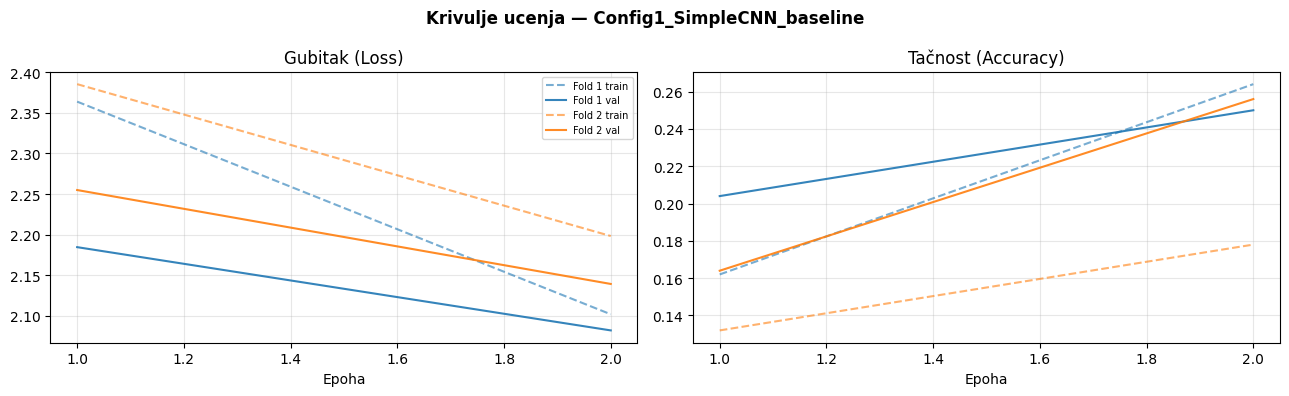

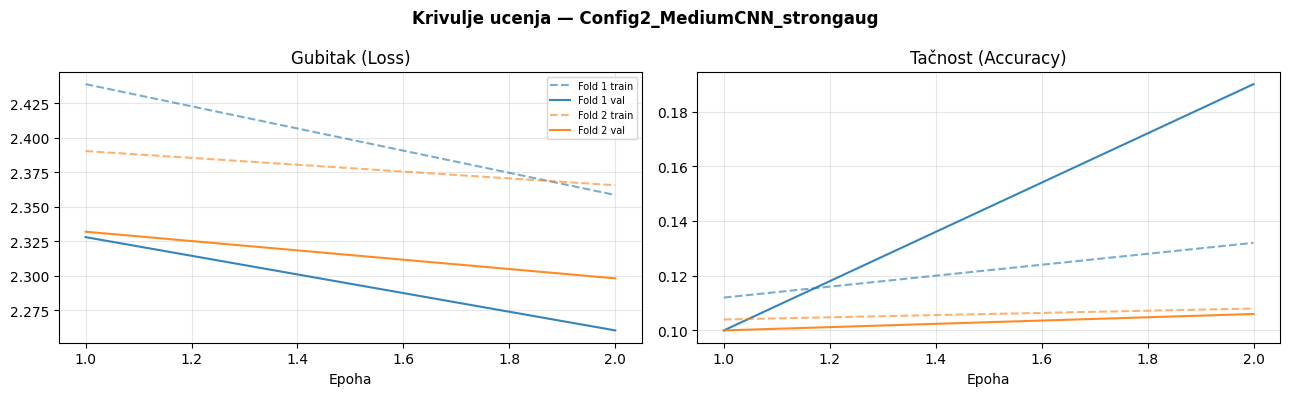

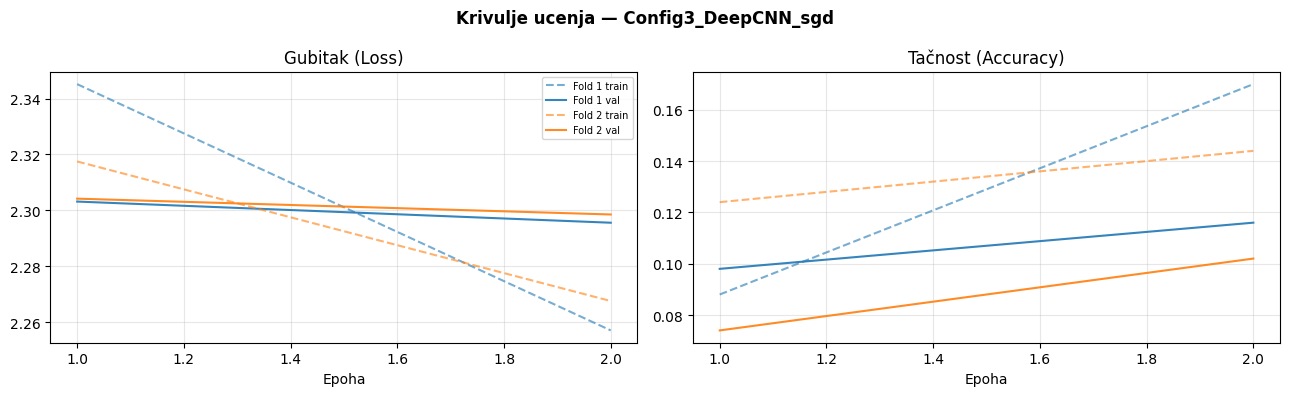

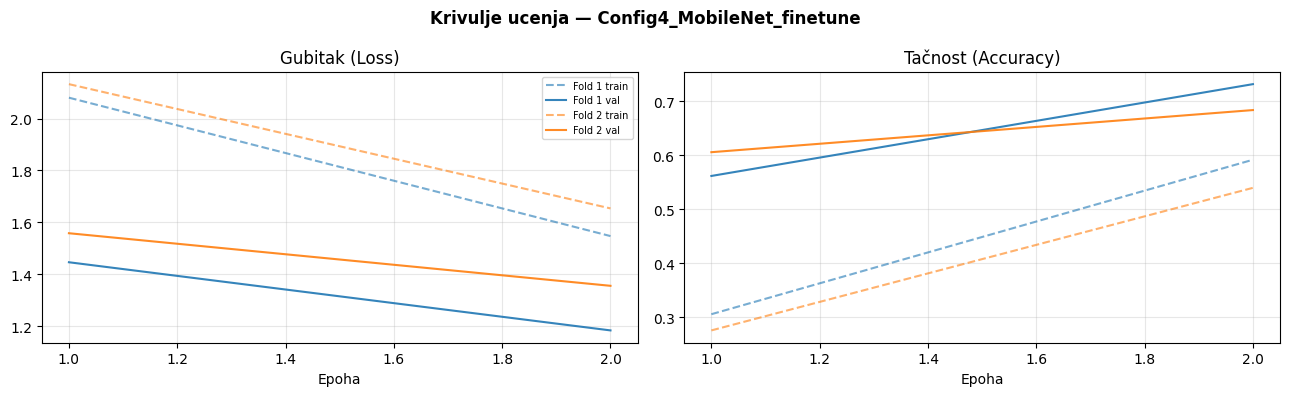

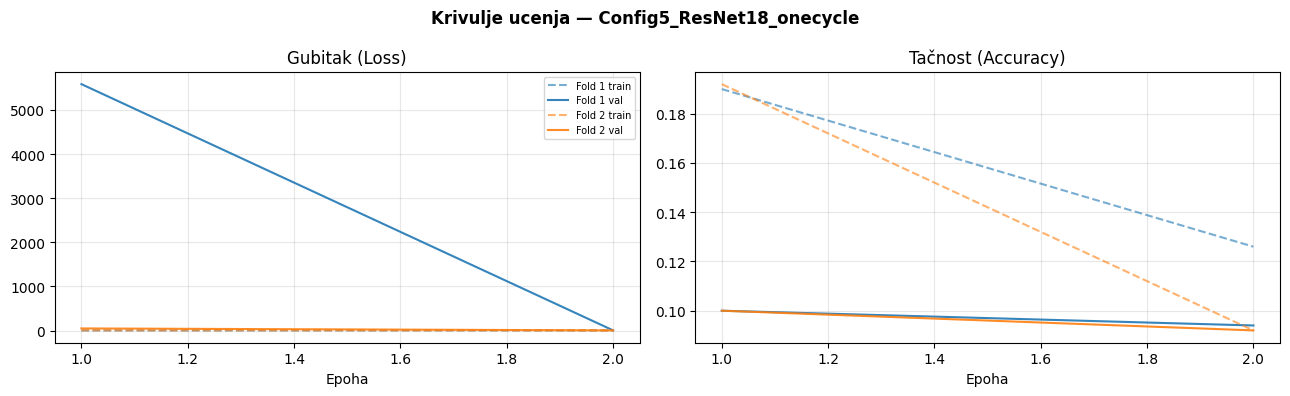

In [ ]:
for cfg in CONFIGS:
    fold_results = cfg['_results']
    name         = cfg['name']
    Path(f'results/{name}').mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Krive učenja — {name}', fontsize=12, fontweight='bold')

    for i, res in enumerate(fold_results):
        ep = range(1, len(res['train_losses']) + 1)
        c  = PAL[i % NUM_CLASSES]
        axes[0].plot(ep, res['train_losses'], '--', color=c, alpha=0.6, label=f'Fold {i+1} train')
        axes[0].plot(ep, res['val_losses'],   '-',  color=c, alpha=0.9, label=f'Fold {i+1} val')
        axes[1].plot(ep, res['train_accs'],   '--', color=c, alpha=0.6)
        axes[1].plot(ep, res['val_accs'],     '-',  color=c, alpha=0.9)

    for ax, lbl in zip(axes, ['Gubitak (Loss)', 'Tačnost (Accuracy)']):
        ax.set_title(lbl); ax.set_xlabel('Epoha'); ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(f'results/{name}/learning_curves.png', dpi=120, bbox_inches='tight')
    plt.show()